In [1]:
# Автоматическая подгрузка обновлений из src
%reload_ext autoreload

# Чтобы торч не мучал warning-ами
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datagen import *
from neuralGMM import NeuralSwitchingGMM
from utils import train_model, diagnose_training
from torch.utils.data import DataLoader
import torch.optim as optim
from data_prep import TimeSeriesDatasetWithChangePoints, create_dataloaders
from plot_tools import *

# Бейзлайн - Гауссовские смеси + RNN (НейроКалман для бинарного латента)

## Параметры GMM в неограниченном пространстве

Для корректного усреднения параметров мы работаем в **неограниченных пространствах**:

| Параметр | Ограничение | Внутреннее представление | Преобразование |
|----------|-------------|--------------------------|----------------|
| Среднее $\mu_k$ | $\mathbb{R}$ | $\tilde{\mu}_k \in \mathbb{R}$ | $\mu_k = \tilde{\mu}_k$ |
| Дисперсия $\sigma_k^2$ | $\mathbb{R}^+$ | $\tilde{v}_k = \log \sigma_k^2 \in \mathbb{R}$ | $\sigma_k = \exp(\tilde{v}_k / 2)$ |
| Веса $\pi_k$ | $\sum \pi_k = 1$ | $\tilde{l}_k \in \mathbb{R}$ (логиты) | $\pi_k = \operatorname{Softmax}(\tilde{l})_k$ |

## Рекуррентное обновление состояния

Итоговые параметры в момент времени $t$ вычисляются как взвешенная комбинация:

$$
\tilde{\theta}_t^{\text{final}} = \alpha_t \cdot \tilde{\theta}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{\theta}_{t-1}^{\text{final}}
$$

где $\tilde{\theta}$ — параметры в неограниченном пространстве, а $\alpha_t \in (0, 1)$ — вероятность точки изменения.

В развёрнутом виде для каждого типа параметров:

$$
\begin{aligned}
\tilde{\mu}_t^{\text{final}} &= \alpha_t \cdot \tilde{\mu}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{\mu}_{t-1}^{\text{final}} \\
\tilde{v}_t^{\text{final}} &= \alpha_t \cdot \tilde{v}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{v}_{t-1}^{\text{final}} \\
\tilde{l}_t^{\text{final}} &= \alpha_t \cdot \tilde{l}_t^{\text{new}} + (1 - \alpha_t) \cdot \tilde{l}_{t-1}^{\text{final}}
\end{aligned}
$$

## Правдоподобие GMM

Плотность вероятности в момент времени $t$ задаётся смесью гауссиан:

$$
p(x_t | \theta_t) = \sum_{k=1}^{K} \pi_{t,k} \cdot \mathcal{N}(x_t | \mu_{t,k}, \sigma_{t,k}^2)
$$

где гауссова плотность:

$$
\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{1}{2} \left(\frac{x - \mu}{\sigma}\right)^2\right)
$$

Для численной устойчивости мы вычисляем логарифм правдоподобия, используя приём log-sum-exp:

$$
\log p(x_t | \theta_t) = \operatorname{LogSumExp}_{k=1}^{K} \left( \log \pi_{t,k} + \log \mathcal{N}(x_t | \mu_{t,k}, \sigma_{t,k}^2) \right)
$$

## Функция потерь

Общая функция потерь состоит из трёх компонент:

$$
\mathcal{L} = \mathcal{L}_{\text{NLL}} + \lambda \cdot \mathcal{L}_{\text{sparsity}} + \beta \cdot \mathcal{L}_{\text{entropy}}
$$

### Отрицательное логарифмическое правдоподобие:
$$
\mathcal{L}_{\text{NLL}} = -\frac{1}{T} \sum_{t=1}^{T} \log p(x_t | \theta_t)
$$

### Штраф за разреженность:
$$
\mathcal{L}_{\text{sparsity}} = \frac{1}{T} \sum_{t=1}^{T} \alpha_t
$$

### Штраф за бинарную энтропию:
$$
\mathcal{L}_{\text{entropy}} = \frac{1}{T} \sum_{t=1}^{T} H(\alpha_t)
$$

где бинарная энтропия определяется как:

$$
H(\alpha) = -\left[ \alpha \log \alpha + (1 - \alpha) \log (1 - \alpha) \right]
$$

---

# Архитектура нейронной сети

## RNN-кодировщик

Скрытое состояние в момент времени $t$ вычисляется следующим образом:

$$
h_t = \text{RNN}(x_t, h_{t-1}; \phi_{\text{rnn}})
$$

где $\phi_{\text{rnn}}$ — параметры RNN.

## Детектор точек изменения

$$
\alpha_t = \operatorname{Sigmoid}(W_{\alpha} h_t + b_{\alpha})
$$

## Выходные головы для параметров GMM

$$
\begin{aligned}
\tilde{\mu}_t^{\text{new}} &= W_{\mu} h_t + b_{\mu} \\
\tilde{v}_t^{\text{new}} &= W_{v} h_t + b_{v} \\
\tilde{l}_t^{\text{new}} &= W_{l} h_t + b_{l}
\end{aligned}
$$

---

# Инференс и обнаружение точек изменения

## Идентификация точек изменения

После обучения точки изменения определяются пороговым значением $\alpha_t$:

$$
z_t = \mathbb{I}(\alpha_t > \tau)
$$

где $\tau \in (0, 1)$ — порог (обычно $\tau = 0.5$), а $\mathbb{I}(\cdot)$ — индикаторная функция.

## Постобработка

Для удаления слишком близко расположенных точек изменения применяется подавление немаксимумов:

$$
z_t^{\text{final}} = 
\begin{cases}
1, & \text{если } z_t = 1 \text{ и } \sum_{j=t-d}^{t-1} z_j = 0 \\
0, & \text{иначе}
\end{cases}
$$

где $d$ — минимальное расстояние между точками изменения.

---

# Алгоритм обучения

**Вход:** временной ряд $X = \{x_1, \dots, x_T\}$, гиперпараметры $\lambda, \beta$  
**Инициализация:** $\theta_0^{\text{final}}$ (обучаемые параметры)

Для epoch = 1 до $N_{\text{epochs}}$:
   Для батча $X^{(b)}$ в DataLoader:

1. Вычислить скрытые состояния: $h_t = \text{RNN}(x_t, h_{t-1})$
2. Вычислить вероятности изменения: $\alpha_t = \operatorname{Sigmoid}(W_{\alpha} h_t + b_{\alpha})$
3. Вычислить новые параметры: $\tilde{\theta}_t^{\text{new}} = \text{MLP}(h_t)$
4. Обновить состояние: $\tilde{\theta}_t^{\text{final}} = \alpha_t \tilde{\theta}_t^{\text{new}} + (1-\alpha_t) \tilde{\theta}_{t-1}^{\text{final}}$
5. Преобразовать в допустимые параметры: $\theta_t = \text{Transform}(\tilde{\theta}_t^{\text{final}})$
6. Вычислить правдоподобие: $p(x_t | \theta_t)$ (используя плотность GMM)
7. Вычислить потери: $\mathcal{L}$ (общая функция потерь)
8. Обновить параметры с помощью градиентного спуска

**Выход:** обученная модель

---

# Гиперпараметры

| Параметр | Рекомендуемый диапазон | Описание |
|----------|------------------------|----------|
| $\text{hidden\_dim}$ | 32–128 | Размерность скрытого состояния RNN |
| $n_{\text{components}}$ | 2–5 | Количество компонент GMM |
| $\lambda$ | 0.001–0.1 | Коэффициент регуляризации разреженности |
| $\beta$ | 0.0001–0.01 | Коэффициент бинарной энтропии |
| $\tau$ | 0.3–0.7 | Порог обнаружения точки изменения |
| $d_{\text{min}}$ | 3–10 | Минимальное расстояние между точками изменения |

---

# Вычисление градиентов

Градиент функции потерь по $\alpha_t$:

$$
\frac{\partial \mathcal{L}}{\partial \alpha_t} = 
\underbrace{\frac{\partial \mathcal{L}_{\text{NLL}}}{\partial \theta_t} \cdot \frac{\partial \theta_t}{\partial \alpha_t}}_{\text{через правдоподобие}} +
\underbrace{\lambda}_{\text{разреженность}} +
\underbrace{\beta \cdot \frac{\partial H(\alpha_t)}{\partial \alpha_t}}_{\text{энтропия}}
$$

где:

$$
\frac{\partial H(\alpha)}{\partial \alpha} = -\log \alpha + \log (1 - \alpha)
$$

и:

$$
\frac{\partial \theta_t}{\partial \alpha_t} = \tilde{\theta}_t^{\text{new}} - \tilde{\theta}_{t-1}^{\text{final}}
$$


# Нотация

| Символ | Значение |
|--------|----------|
| $x_t$ | Наблюдение в момент времени $t$ |
| $h_t$ | Скрытое состояние RNN в момент времени $t$ |
| $\alpha_t$ | Вероятность точки изменения в момент $t$ |
| $\theta_t$ | Параметры GMM в момент $t$ |
| $\mu_{t,k}$ | Среднее $k$-й компоненты GMM в момент $t$ |
| $\sigma_{t,k}$ | Стандартное отклонение $k$-й компоненты |
| $\pi_{t,k}$ | Вес $k$-й компоненты GMM |
| $K$ | Количество компонент GMM |
| $T$ | Длина последовательности |
| $B$ | Размер батча |
| $\lambda$ | Коэффициент регуляризации разреженности |
| $\beta$ | Коэффициент регуляризации энтропии |
| $\tau$ | Порог обнаружения |

---

In [9]:
means = np.array([[-10, 0, 10],
                  [-15, 0, 15],
                  [-10, 0, 10],
                  [-15, 0, 15],
                  [-10, 0, 10],
                  [-15, 0, 15],
                  [-10, 0, 10],
                  [-15, 0, 15],
                  [-10, 0, 10],
                  [-15, 0, 15]])

variances = np.array([[10, 3, 10],
                      [15, 9, 15],
                      [10, 3, 10],
                      [15, 9, 15],
                      [10, 3, 10],
                      [15, 9, 15],
                      [10, 3, 10],
                      [15, 9, 15],
                      [10, 3, 10],
                      [15, 9, 15]])

weights = np.array([[0.25, 0.5, 0.25],
                    [0.1, 0.8, 0.1],
                    [0.25, 0.5, 0.25],
                    [0.1, 0.8, 0.1],
                    [0.25, 0.5, 0.25],
                    [0.1, 0.8, 0.1],
                    [0.25, 0.5, 0.25],
                    [0.1, 0.8, 0.1],
                    [0.25, 0.5, 0.25],
                    [0.1, 0.8, 0.1]])

generator = GMMChangePointGenerator(10_000, 
                                    [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000], 
                                    3, 
                                    means,
                                    variances,
                                    weights
                                    )

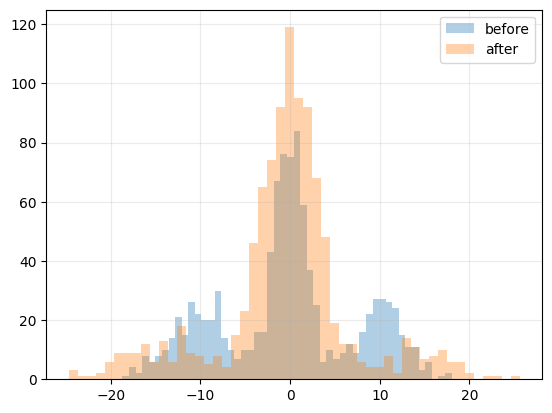

In [12]:
obs = generator.generate()
data, regimes = obs[0], obs[1]

plt.hist(data[:1000], bins =50, label = 'before', alpha=0.35)
plt.hist(data[1000:2000], bins =50, label = 'after', alpha=0.35)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

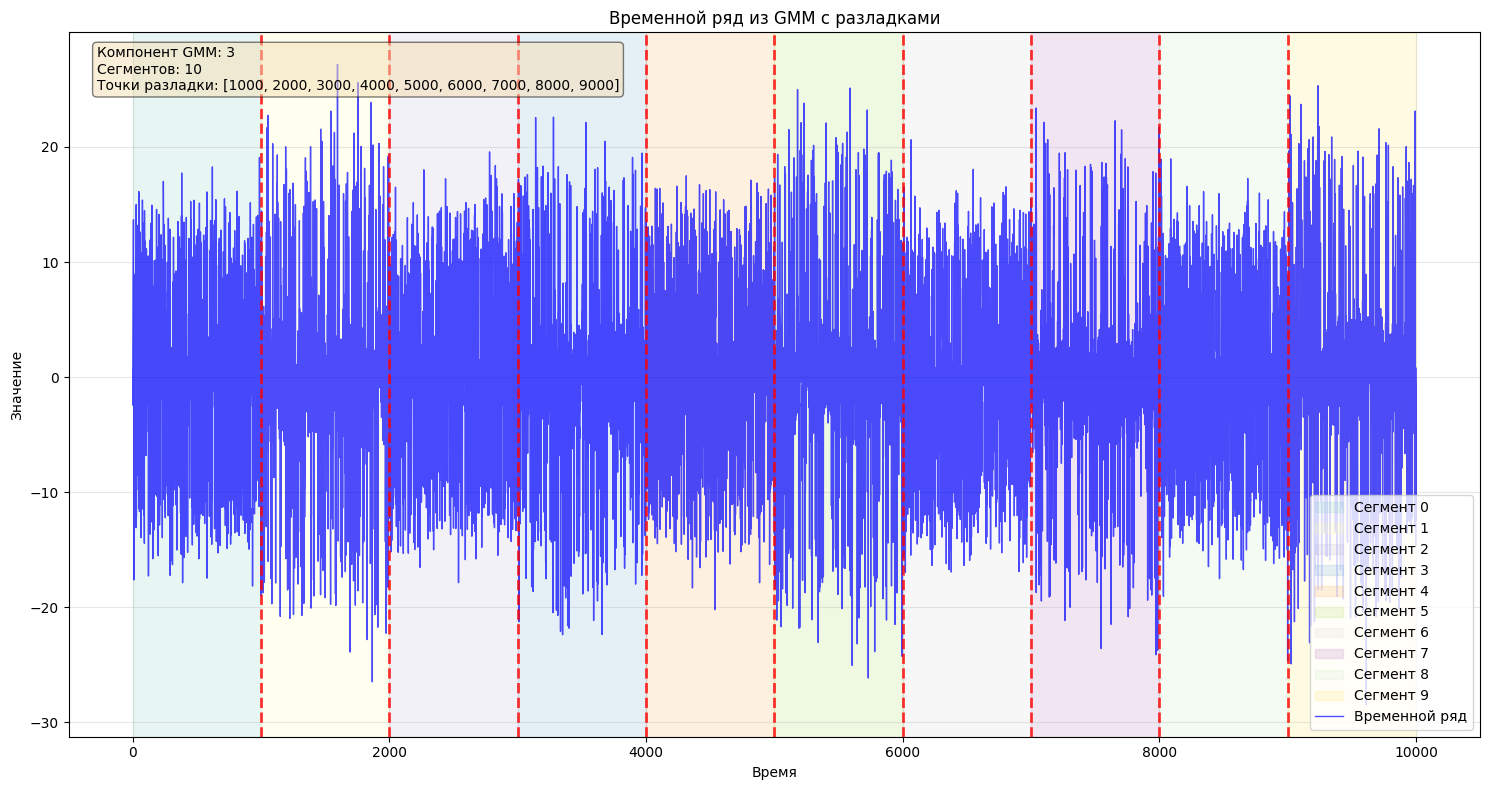

(<Figure size 1500x800 with 1 Axes>,
 <Axes: title={'center': 'Временной ряд из GMM с разладками'}, xlabel='Время', ylabel='Значение'>)

In [13]:
generator.visualize()

In [14]:
changepoints = np.zeros(10_000)
changepoints[1000] = 1
changepoints[2000] = 1
changepoints[3000] = 1
changepoints[4000] = 1
changepoints[5000] = 1
changepoints[6000] = 1
changepoints[7000] = 1
changepoints[8000] = 1
changepoints[9000] = 1

dataset = TimeSeriesDatasetWithChangePoints(data, 
                                            changepoints, 
                                            64,
                                            1)
loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=False,
)

loader_sorted = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False,
    drop_last=True,
    num_workers=0,
    pin_memory=False,
)


Dataset создан: 9937 последовательностей длиной 64
Статистика: mean=-0.0765, std=7.4562


In [19]:
model = NeuralSwitchingGMM(
    1,
    16,
    3,
    5.0,
    0.25,
)
model.to('cuda')

optimizer = optim.AdamW(  # AdamW лучше отделяет weight_decay от градиентов
        model.parameters(),
        lr=1e-3,
        betas=(0.9, 0.99),
        eps=1e-8,
        weight_decay=1e-5,
    )

In [20]:
train_model(model,
            loader,
            optimizer,
            250,
            device='cuda'
            )

Epoch 1/250: Loss=1.6194, NLL=1.3604, Sparsity=0.0457
Epoch 2/250: Loss=1.3321, NLL=1.3081, Sparsity=0.0038
Epoch 3/250: Loss=1.3139, NLL=1.3019, Sparsity=0.0020
Epoch 4/250: Loss=1.3088, NLL=1.3011, Sparsity=0.0013
Epoch 5/250: Loss=1.3062, NLL=1.3008, Sparsity=0.0009
Epoch 6/250: Loss=1.3046, NLL=1.3008, Sparsity=0.0006
Epoch 7/250: Loss=1.3035, NLL=1.3008, Sparsity=0.0004
Epoch 8/250: Loss=1.3025, NLL=1.3006, Sparsity=0.0003
Epoch 9/250: Loss=1.3017, NLL=1.3006, Sparsity=0.0002
Epoch 10/250: Loss=1.3010, NLL=1.3005, Sparsity=0.0001
Epoch 11/250: Loss=1.3005, NLL=1.3004, Sparsity=0.0000
Epoch 12/250: Loss=1.3004, NLL=1.3004, Sparsity=0.0000
Epoch 13/250: Loss=1.3004, NLL=1.3004, Sparsity=0.0000
Epoch 14/250: Loss=1.3004, NLL=1.3004, Sparsity=0.0000
Epoch 15/250: Loss=1.3004, NLL=1.3004, Sparsity=0.0000
Epoch 16/250: Loss=1.3004, NLL=1.3004, Sparsity=0.0000
Epoch 17/250: Loss=1.3004, NLL=1.3004, Sparsity=0.0000
Epoch 18/250: Loss=1.3004, NLL=1.3004, Sparsity=0.0000
Epoch 19/250: Loss=

{'total': [1.619383179815111,
  1.3321075086240415,
  1.3139296509025562,
  1.3088137429693472,
  1.3061772129961833,
  1.3045794069287089,
  1.303483939977084,
  1.30247835682978,
  1.3016931617125604,
  1.3010484308436296,
  1.3005421180847954,
  1.3003616953049688,
  1.3003643578377322,
  1.3003798675229967,
  1.3003997274834944,
  1.3003545037790196,
  1.3003817487646032,
  1.3003712527801834,
  1.3003798757774243,
  1.3003765256316573,
  1.3003944559757645,
  1.3003684710381305,
  1.300371166780567,
  1.300383559939558,
  1.3003533614046523,
  1.3003666498810773,
  1.3003940065893766,
  1.3003756061268315,
  1.3003642104098185,
  1.3003725940286632,
  1.3003684053866376,
  1.3004018763221212,
  1.3003547358628056,
  1.3003646928139163,
  1.3003562086062348,
  1.3003678041571771,
  1.3004061726556309,
  1.300351854491733,
  1.300356169829622,
  1.3003647724787395,
  1.3003601073834823,
  1.3003638589247797,
  1.3003487229923119,
  1.3003833556904694,
  1.300365951134195,
  1.300368

In [21]:
def extract_gmm_parameters(
    model: torch.nn.Module,
    data: torch.Tensor,
    device: str = 'cpu',
) -> Dict[str, np.ndarray]:
    """
    Извлечение всех параметров GMM для каждого шага времени.
    
    Args:
        model: Обученная NeuralSwitchingGMM
        data: Временной ряд [T] или [T, 1]
        device: Устройство для вычислений
        
    Returns:
        Dictionary с параметрами:
        - 'mu': [T, K] — средние значения
        - 'sigma': [T, K] — стандартные отклонения
        - 'pi': [T, K] — веса компонент
        - 'alpha': [T] — вероятность разладки
        - 'log_prob': [T] — лог-правдоподобие
    """
    model.eval()
    
    # Подготовка данных
    if isinstance(data, np.ndarray):
        data = torch.from_numpy(data).float()
    
    if data.dim() == 1:
        data = data.unsqueeze(-1)  # [T, 1]
    
    # Добавляем batch dimension
    x = data.unsqueeze(0).to(device)  # [1, T, 1]
    
    # Forward pass с возвратом состояний
    with torch.no_grad():
        _, outputs = model(x, return_states=True)
    
    # Извлечение параметров
    params = outputs['params']
    
    results = {
        'mu': params['mu'].squeeze(0).cpu().numpy(),      # [T, K]
        'sigma': params['sigma'].squeeze(0).cpu().numpy(), # [T, K]
        'pi': params['pi'].squeeze(0).cpu().numpy(),       # [T, K]
        'alpha': outputs['alpha'].squeeze(0).squeeze(-1).cpu().numpy(),  # [T]
        'log_prob': outputs['log_prob'].squeeze(0).cpu().numpy(),  # [T]
    }
    
    # Дополнительная статистика
    results['dominant_component'] = np.argmax(results['pi'], axis=1)  # [T]
    results['weighted_mean'] = np.sum(results['pi'] * results['mu'], axis=1)  # [T]
    results['weighted_std'] = np.sqrt(
        np.sum(results['pi'] * (results['sigma']**2 + results['mu']**2), axis=1)  
        - results['weighted_mean']**2                                           
        )
    
    return results

In [22]:
params = extract_gmm_parameters(model, data, device='cuda')

mu_real = np.concat((np.tile(np.array([-10, 0, 10]), (5000, 1)), np.tile(np.array([-15, 0, 15]), (5000, 1))))
var_real = np.sqrt(np.concat((np.tile(np.array([10, 3, 10]), (5000, 1)), np.tile(np.array([15, 9, 15]), (5000, 1)))))
weights_real = np.concat((np.tile(np.array([0.25, 0.5, 0.25]), (5000, 1)), np.tile(np.array([0.1, 0.8, 0.1]), (5000, 1))))

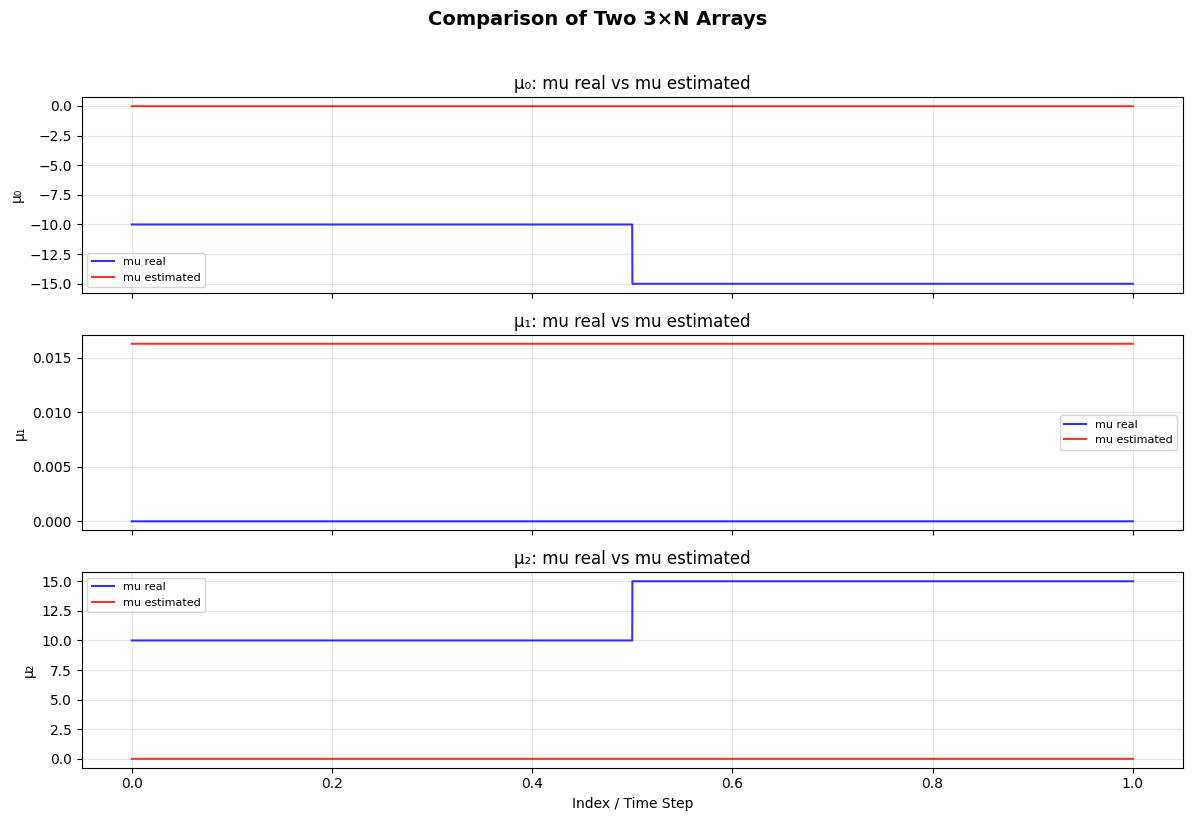

📊 Статистика покомпонентного сравнения:
   Компонента 0: mean|Δ|=12.4725, max|Δ|=14.9725, corr=nan
   Компонента 1: mean|Δ|=0.0163, max|Δ|=0.0163, corr=nan
   Компонента 2: mean|Δ|=12.5005, max|Δ|=15.0005, corr=nan


In [23]:
plot_3xN_comparison(
    mu_real.T, params['mu'].T,
    labels=('mu real', 'mu estimated'),
    component_names=('μ₀', 'μ₁', 'μ₂'),
    x_axis=np.linspace(0,1,10000),
)

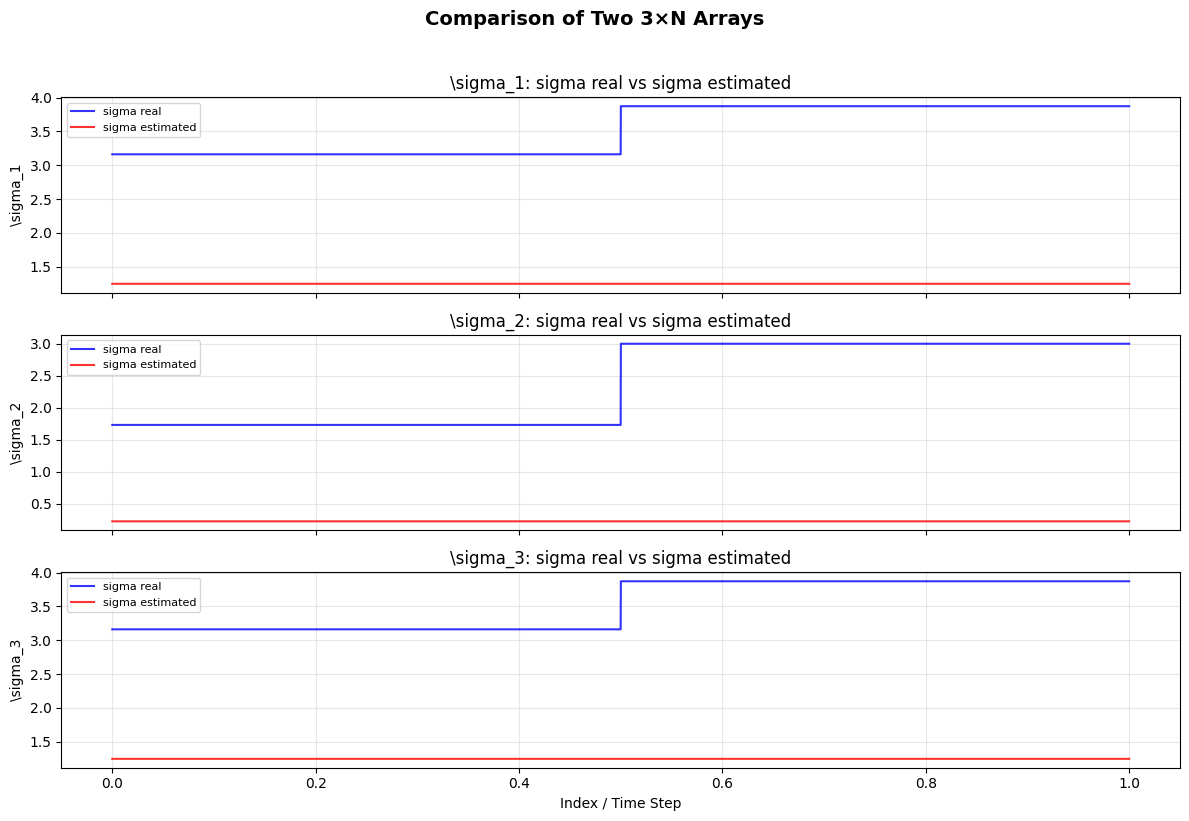

📊 Статистика покомпонентного сравнения:
   Компонента 0: mean|Δ|=2.2701, max|Δ|=2.6255, corr=nan
   Компонента 1: mean|Δ|=2.1400, max|Δ|=2.7740, corr=nan
   Компонента 2: mean|Δ|=2.2704, max|Δ|=2.6258, corr=nan


In [24]:
plot_3xN_comparison(
    var_real.T, params['sigma'].T,
    labels=('sigma real', 'sigma estimated'),
    component_names=(r'\sigma_1', r'\sigma_2', r'\sigma_3'),
    x_axis=np.linspace(0,1,10000),
)

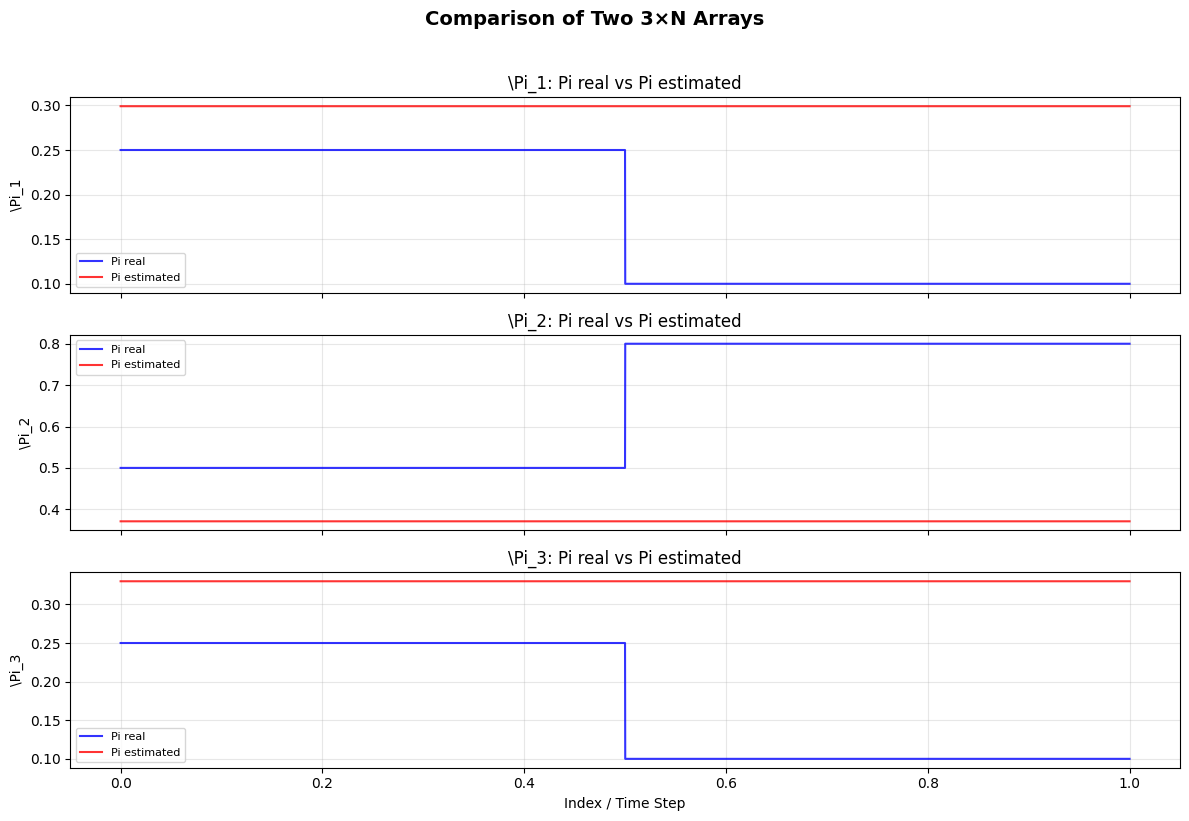

📊 Статистика покомпонентного сравнения:
   Компонента 0: mean|Δ|=0.1241, max|Δ|=0.1991, corr=nan
   Компонента 1: mean|Δ|=0.2790, max|Δ|=0.4290, corr=nan
   Компонента 2: mean|Δ|=0.1549, max|Δ|=0.2299, corr=nan


In [25]:
plot_3xN_comparison(
    weights_real.T, params['pi'].T,
    labels=('Pi real', 'Pi estimated'),
    component_names=(r'\Pi_1', r'\Pi_2', r'\Pi_3'),
    x_axis=np.linspace(0,1,10000),
)